In [ ]:
# Hafta 5


# Konu: 
    ## Bir modelin gradient'lerini loss.backward() olmadan, elle hesaplamak. 

# Bu hafta öğrenilecekler:
    ## Her ara değişkenin gradient'ini elle yazmak ve PyTorch'unkiyle karşılaştırmak
    ## Broadcasting'in gradient'e etkisi: toplanan boyut geri dönerken nerede sum alınır
    ## Cross entropy ve BatchNorm'un türevlerinin neden tek satıra indiği



# Bu haftanın görevi:

    ## 1. Geçen haftaki MLP + BatchNorm modelini videodaki gibi küçük adımlara böl (logits, counts, probs, logprobs, ...) ve loss.backward() ile her ara değişkenin gradient'ini al.
    ## 2. Aynı gradient'leri elle yaz, cmp fonksiyonuyla tek tek karşılaştır. Hepsi "exact" ya da "approximate" olana kadar devam et. Takıldığın türevi videoda bul, ama önce kendin dene.
    ## 3. Ek, isteyenler için: cross entropy'nin ve BatchNorm'un geriye yayılımını tek ifadeye indir ve modeli loss.backward() olmadan kendi gradient'lerinle eğit.

In [ ]:
# hazırlık

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])
4137


tensor(3.3352, grad_fn=<NegBackward0>)

In [ ]:
# Görev 1: 
  ## Geçen haftaki MLP + BatchNorm modelini videodaki gibi küçük adımlara böl 
    ### (logits, counts, probs, logprobs, ...) 
  ## ve loss.backward() ile her ara değişkenin gradient'ini al.

n_embd = 10 
n_hidden = 64

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parametreleri
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1


parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # total parametre sayısı
for p in parameters:
  p.requires_grad = True

batch_size = 32

# minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

# forward pass
emb = C[Xb] 
embcat = emb.view(emb.shape[0], -1)
# Linear layer 1
hprebn = embcat @ W1 + b1 
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (F.cross_entropy(logits, Yb) ile aynı)
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # numerical stability için
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

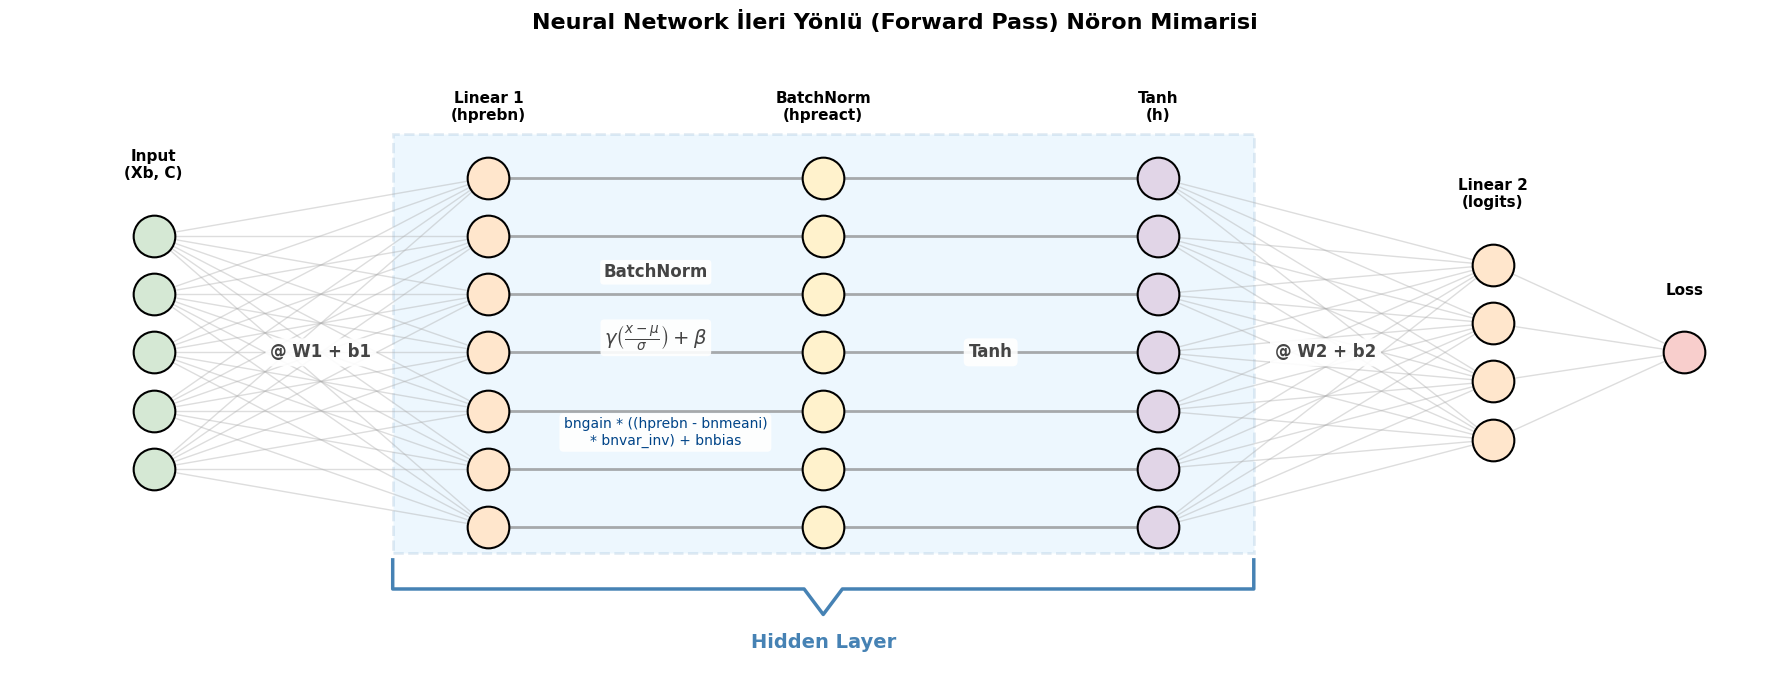

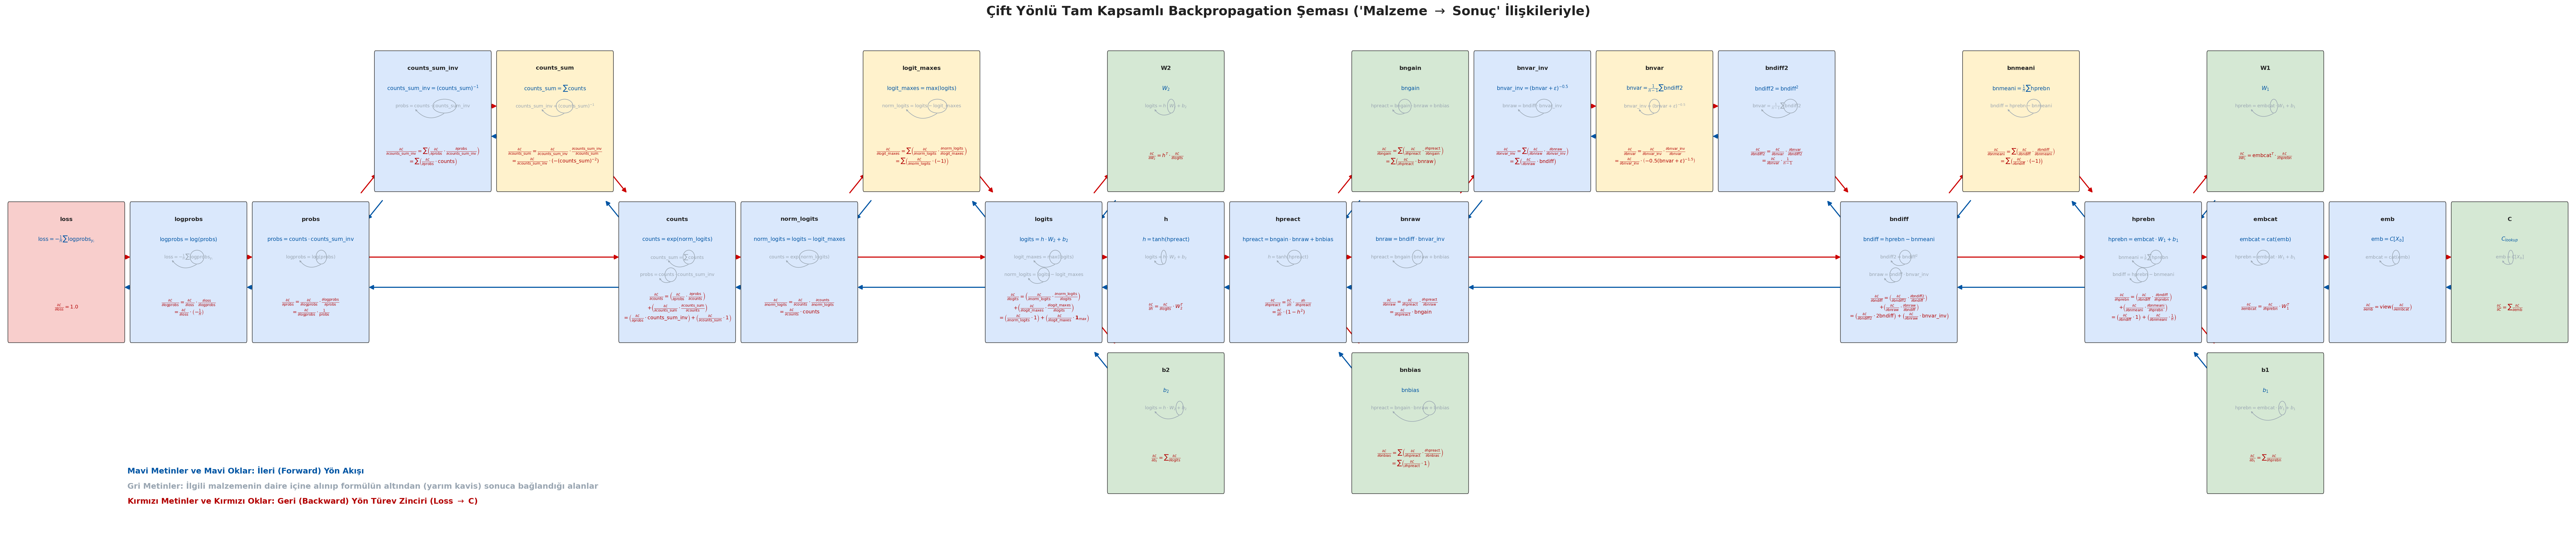

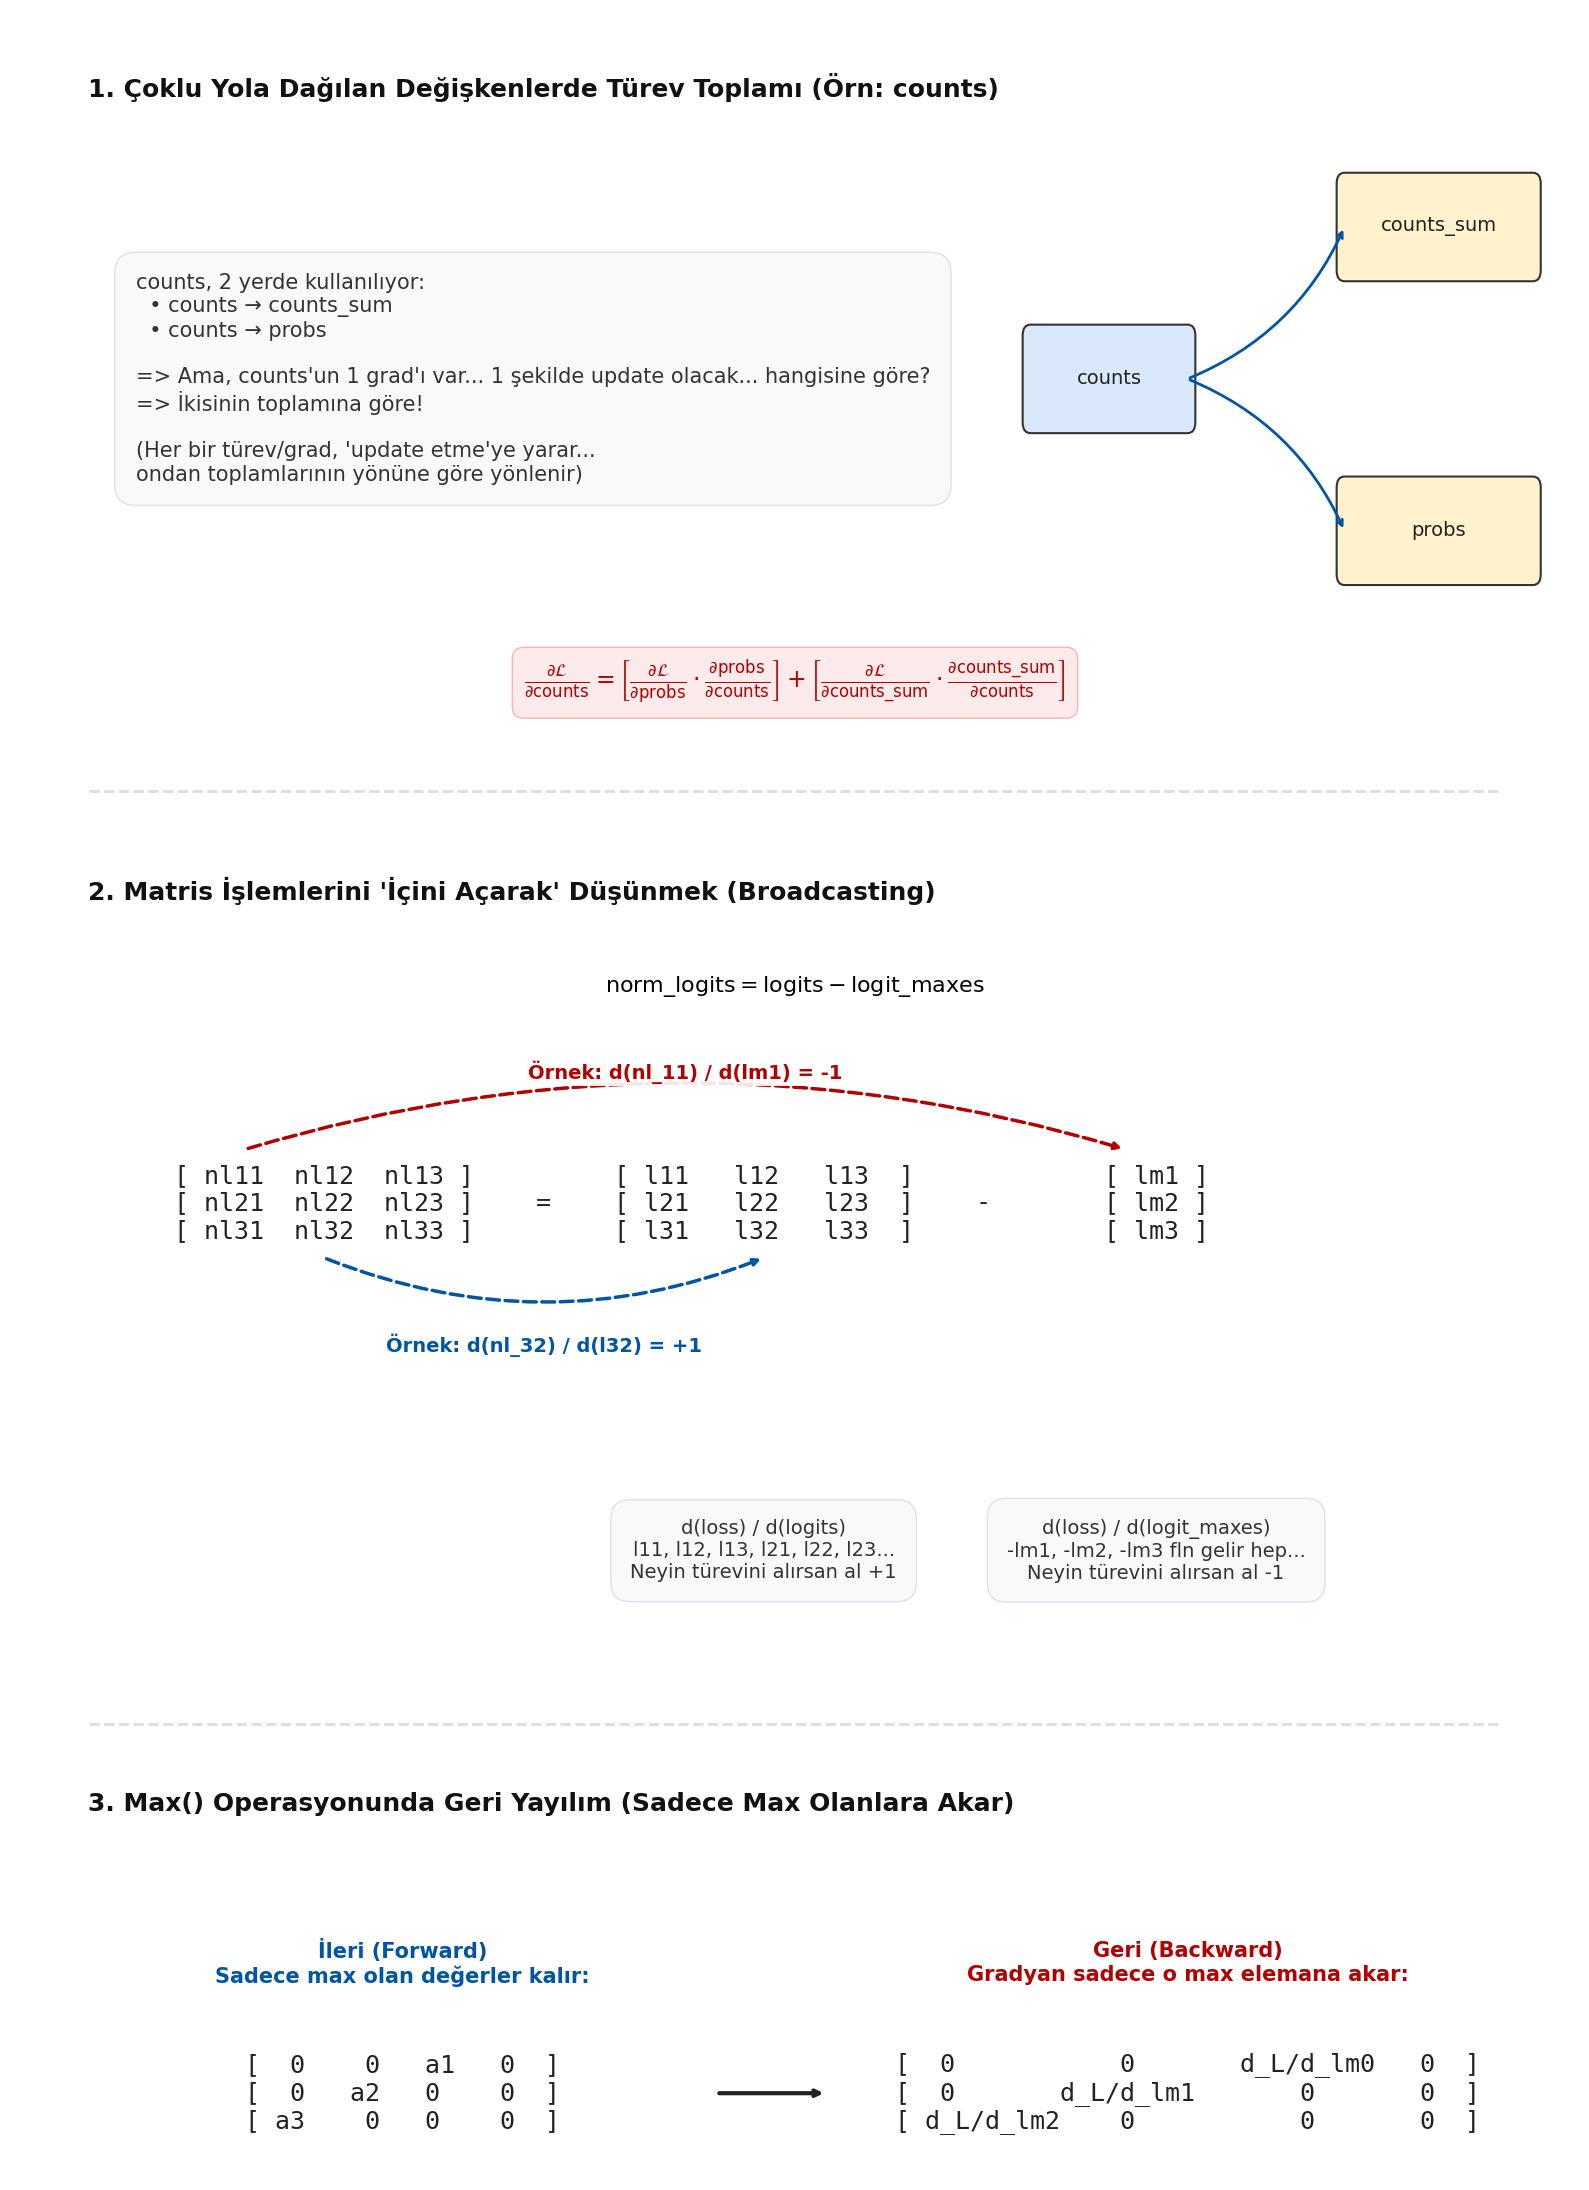

In [104]:
# görselleştirme

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

# =====================================================================
# 1. KISIM: Neural Network İleri Yönlü (Forward Pass) Nöron Mimarisi
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(18, 7)) 
fig1.patch.set_facecolor('white')
ax1.axis('off')

layers = [
    ("Input\n(Xb, C)", 1.5, 5, '#D5E8D4'),
    ("Linear 1\n(hprebn)", 5.0, 7, '#FFE6CC'),
    ("BatchNorm\n(hpreact)", 8.5, 7, '#FFF2CC'),
    ("Tanh\n(h)", 12.0, 7, '#E1D5E7'),
    ("Linear 2\n(logits)", 15.5, 4, '#FFE6CC'),
    ("Loss", 17.5, 1, '#F8CECC')
]

box = patches.Rectangle((4.0, -0.05), 9.0, 1.15, fill=True, color='#87CEFA', alpha=0.15, ec='#4682B4', lw=2, linestyle='--', zorder=0)
ax1.add_patch(box)

x_left, x_right = 4.0, 13.0
ym, yb, yc = -0.07, -0.15, -0.22 
mid = (x_left + x_right) / 2

ax1.plot([x_left, x_left, mid - 0.2, mid, mid + 0.2, x_right, x_right],
         [ym, yb, yb, yc, yb, yb, ym], color='#4682B4', lw=2.5, clip_on=False)
ax1.text(mid, yc - 0.05, "Hidden Layer", ha='center', va='top', fontsize=14, fontweight='bold', color='#4682B4')

node_coords = []
dy = 0.16 
for name, x, n, color in layers:
    y_coords = [0.5 + (i - (n - 1) / 2) * dy for i in range(n)]
    node_coords.append((x, y_coords, color, name))
    
for i in range(len(node_coords) - 1):
    x1_coord, y_coords1, _, _ = node_coords[i]
    x2_coord, y_coords2, _, _ = node_coords[i+1]
    
    mid_x = (x1_coord + x2_coord) / 2
    
    if i == 1:
        for y1, y2 in zip(y_coords1, y_coords2):
            ax1.plot([x1_coord, x2_coord], [y1, y2], color='#888888', alpha=0.7, lw=2, zorder=1)
        ax1.text(mid_x, 0.72, "BatchNorm", ha='center', va='center', fontsize=12, fontweight='bold', color='#444444', bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.2'))
        ax1.text(mid_x, 0.54, r"$\gamma \left( \frac{x - \mu}{\sigma} \right) + \beta$", ha='center', va='center', fontsize=14, color='#444444', bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.2'))
        code_text = "bngain * ((hprebn - bnmeani)\n* bnvar_inv) + bnbias"
        ax1.text(mid_x + 0.1, 0.28, code_text, ha='center', va='center', fontsize=10, color='#004488', bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.3'))
    elif i == 2:
        for y1, y2 in zip(y_coords1, y_coords2):
            ax1.plot([x1_coord, x2_coord], [y1, y2], color='#888888', alpha=0.7, lw=2, zorder=1)
        ax1.text(mid_x, 0.5, "Tanh", ha='center', va='center', fontsize=12, fontweight='bold', color='#444444', bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.3'))
    else:
        for y1 in y_coords1:
            for y2 in y_coords2:
                ax1.plot([x1_coord, x2_coord], [y1, y2], color='#AAAAAA', alpha=0.4, lw=1, zorder=1)
        if i == 0:
            ax1.text(mid_x, 0.5, "@ W1 + b1", ha='center', va='center', fontsize=12, fontweight='bold', color='#444444', bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.3'))
        elif i == 3:
            ax1.text(mid_x, 0.5, "@ W2 + b2", ha='center', va='center', fontsize=12, fontweight='bold', color='#444444', bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.3'))

for x, y_coords, color, name in node_coords:
    x_vals = [x] * len(y_coords)
    ax1.scatter(x_vals, y_coords, s=900, c=color, edgecolors='black', linewidths=1.5, zorder=2)
    ax1.text(x, max(y_coords) + 0.15, name, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlim(0, 18.5)
ax1.set_ylim(-0.4, 1.35)
ax1.set_title("Neural Network İleri Yönlü (Forward Pass) Nöron Mimarisi", fontsize=16, fontweight='bold', pad=10)

plt.tight_layout()
plt.show() # İlk şekli ekrana basar


# =====================================================================
# 2. KISIM: Çift Yönlü Tam Kapsamlı Backpropagation Şeması
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(100, 21))
fig2.patch.set_facecolor('#ffffff')
ax2.axis('off')

def draw_node(ax, x, y, title, main_fwd, faint_list, bwd, color='#e6f2ff'):
    bw, bh = 5.4, 2.7 
    box = patches.FancyBboxPatch((x-bw, y-bh), 2*bw, 2*bh, boxstyle="round,pad=0.1", 
                                 ec="#333333", fc=color, lw=1.5, zorder=2)
    ax.add_patch(box)
    
    ax.text(x, y+2.1, title, ha='center', va='center', fontweight='bold', fontsize=16, color='#222222', zorder=3)
    ax.text(x, y+1.3, main_fwd, ha='center', va='center', fontsize=15, color='#0055a4', zorder=3)
    
    faint_y_start = 0.6
    faint_y_step = 0.7
    faint_color = '#9aa6b2' 
    
    for i, (f_str, left_dx, right_dx, cw) in enumerate(faint_list):
        fy = y + faint_y_start - i * faint_y_step
        
        ax.text(x, fy, f_str, ha='center', va='center', fontsize=13, color=faint_color, zorder=3)
        
        circ_x = x + right_dx
        ellipse = patches.Ellipse((circ_x, fy), width=cw, height=0.55, 
                                  ec=faint_color, fc='none', lw=1.5, zorder=3)
        ax.add_patch(ellipse)
        
        target_x = x - left_dx
        ax.annotate("", xy=(target_x, fy - 0.1), xytext=(circ_x, fy - 0.28),
                    arrowprops=dict(arrowstyle="->", color=faint_color, lw=1.5, 
                                    connectionstyle="arc3,rad=-0.45"), zorder=3)
        
    ax.text(x, y-1.4, bwd, ha='center', va='center', fontsize=14, color='#b30000', zorder=3)

x_spacing = 11.5
y_top = 6.0
y_mid = 0
y_bot = -6.0

nodes = {
    'loss': (0*x_spacing, y_mid, 'loss', r"$\text{loss} = -\frac{1}{n}\sum \text{logprobs}_{y_i}$", [], r"$\frac{\partial \mathcal{L}}{\partial \text{loss}} = 1.0$", '#f8cecc'),
    'logprobs': (1*x_spacing, y_mid, 'logprobs', r"$\text{logprobs} = \log(\text{probs})$", [(r"$\text{loss} = -\frac{1}{n}\sum \text{logprobs}_{y_i}$", 1.6, 0.8, 1.3)], r"$\frac{\partial \mathcal{L}}{\partial \text{logprobs}} = \frac{\partial \mathcal{L}}{\partial \text{loss}} \cdot \frac{\partial \text{loss}}{\partial \text{logprobs}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial \text{loss}} \cdot \left(-\frac{1}{n}\right)$", '#dae8fc'),
    'probs': (2*x_spacing, y_mid, 'probs', r"$\text{probs} = \text{counts} \cdot \text{counts\_sum\_inv}$", [(r"$\text{logprobs} = \log(\text{probs})$", 1.1, 1.0, 1.0)], r"$\frac{\partial \mathcal{L}}{\partial \text{probs}} = \frac{\partial \mathcal{L}}{\partial \text{logprobs}} \cdot \frac{\partial \text{logprobs}}{\partial \text{probs}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial \text{logprobs}} \cdot \frac{1}{\text{probs}}$", '#dae8fc'),
    'counts_sum_inv': (3*x_spacing, y_top, 'counts_sum_inv', r"$\text{counts\_sum\_inv} = (\text{counts\_sum})^{-1}$", [(r"$\text{probs} = \text{counts} \cdot \text{counts\_sum\_inv}$", 1.7, 1.1, 2.2)], r"$\frac{\partial \mathcal{L}}{\partial \text{counts\_sum\_inv}} = \sum \left( \frac{\partial \mathcal{L}}{\partial \text{probs}} \cdot \frac{\partial \text{probs}}{\partial \text{counts\_sum\_inv}} \right)$" + "\n" + r"$= \sum \left( \frac{\partial \mathcal{L}}{\partial \text{probs}} \cdot \text{counts} \right)$", '#dae8fc'),
    'counts_sum': (4*x_spacing, y_top, 'counts_sum', r"$\text{counts\_sum} = \sum \text{counts}$", [(r"$\text{counts\_sum\_inv} = (\text{counts\_sum})^{-1}$", 1.3, 0.9, 1.6)], r"$\frac{\partial \mathcal{L}}{\partial \text{counts\_sum}} = \frac{\partial \mathcal{L}}{\partial \text{counts\_sum\_inv}} \cdot \frac{\partial \text{counts\_sum\_inv}}{\partial \text{counts\_sum}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial \text{counts\_sum\_inv}} \cdot (-(\text{counts\_sum})^{-2})$", '#fff2cc'),
    'counts': (5*x_spacing, y_mid, 'counts', r"$\text{counts} = \exp(\text{norm\_logits})$", [(r"$\text{counts\_sum} = \sum \text{counts}$", 0.9, 1.1, 1.1), (r"$\text{probs} = \text{counts} \cdot \text{counts\_sum\_inv}$", 1.7, -0.6, 1.1)], r"$\frac{\partial \mathcal{L}}{\partial \text{counts}} = \left( \frac{\partial \mathcal{L}}{\partial \text{probs}} \cdot \frac{\partial \text{probs}}{\partial \text{counts}} \right)$" + "\n" + r"$+ \left( \frac{\partial \mathcal{L}}{\partial \text{counts\_sum}} \cdot \frac{\partial \text{counts\_sum}}{\partial \text{counts}} \right)$" + "\n" + r"$= \left( \frac{\partial \mathcal{L}}{\partial \text{probs}} \cdot \text{counts\_sum\_inv} \right) + \left( \frac{\partial \mathcal{L}}{\partial \text{counts\_sum}} \cdot 1 \right)$", '#dae8fc'),
    'norm_logits': (6*x_spacing, y_mid, 'norm_logits', r"$\text{norm\_logits} = \text{logits} - \text{logit\_maxes}$", [(r"$\text{counts} = \exp(\text{norm\_logits})$", 1.3, 0.9, 1.8)], r"$\frac{\partial \mathcal{L}}{\partial \text{norm\_logits}} = \frac{\partial \mathcal{L}}{\partial \text{counts}} \cdot \frac{\partial \text{counts}}{\partial \text{norm\_logits}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial \text{counts}} \cdot \text{counts}$", '#dae8fc'),
    'logit_maxes': (7*x_spacing, y_top, 'logit_maxes', r"$\text{logit\_maxes} = \max(\text{logits})$", [(r"$\text{norm\_logits} = \text{logits} - \text{logit\_maxes}$", 1.5, 1.5, 1.8)], r"$\frac{\partial \mathcal{L}}{\partial \text{logit\_maxes}} = \sum \left( \frac{\partial \mathcal{L}}{\partial \text{norm\_logits}} \cdot \frac{\partial \text{norm\_logits}}{\partial \text{logit\_maxes}} \right)$" + "\n" + r"$= \sum \left( \frac{\partial \mathcal{L}}{\partial \text{norm\_logits}} \cdot (-1) \right)$", '#fff2cc'),
    'logits': (8*x_spacing, y_mid, 'logits', r"$\text{logits} = h \cdot W_2 + b_2$", [(r"$\text{logit\_maxes} = \max(\text{logits})$", 1.0, 1.1, 1.1), (r"$\text{norm\_logits} = \text{logits} - \text{logit\_maxes}$", 1.5, 0.0, 1.1)], r"$\frac{\partial \mathcal{L}}{\partial \text{logits}} = \left( \frac{\partial \mathcal{L}}{\partial \text{norm\_logits}} \cdot \frac{\partial \text{norm\_logits}}{\partial \text{logits}} \right)$" + "\n" + r"$+ \left( \frac{\partial \mathcal{L}}{\partial \text{logit\_maxes}} \cdot \frac{\partial \text{logit\_maxes}}{\partial \text{logits}} \right)$" + "\n" + r"$= \left( \frac{\partial \mathcal{L}}{\partial \text{norm\_logits}} \cdot 1 \right) + \left( \frac{\partial \mathcal{L}}{\partial \text{logit\_maxes}} \cdot \mathbf{1}_{max} \right)$", '#dae8fc'),
    'W2': (9*x_spacing, y_top, 'W2', r"$W_2$", [(r"$\text{logits} = h \cdot W_2 + b_2$", 1.1, 0.5, 0.7)], r"$\frac{\partial \mathcal{L}}{\partial W_2} = h^T \cdot \frac{\partial \mathcal{L}}{\partial \text{logits}}$", '#d5e8d4'),
    'b2': (9*x_spacing, y_bot, 'b2', r"$b_2$", [(r"$\text{logits} = h \cdot W_2 + b_2$", 1.1, 1.3, 0.7)], r"$\frac{\partial \mathcal{L}}{\partial b_2} = \sum \frac{\partial \mathcal{L}}{\partial \text{logits}}$", '#d5e8d4'),
    'h': (9*x_spacing, y_mid, 'h', r"$h = \tanh(\text{hpreact})$", [(r"$\text{logits} = h \cdot W_2 + b_2$", 1.1, -0.2, 0.5)], r"$\frac{\partial \mathcal{L}}{\partial h} = \frac{\partial \mathcal{L}}{\partial \text{logits}} \cdot W_2^T$", '#dae8fc'),
    'hpreact': (10*x_spacing, y_mid, 'hpreact', r"$\text{hpreact} = \text{bngain} \cdot \text{bnraw} + \text{bnbias}$", [(r"$h = \tanh(\text{hpreact})$", 1.1, 0.6, 1.3)], r"$\frac{\partial \mathcal{L}}{\partial \text{hpreact}} = \frac{\partial \mathcal{L}}{\partial h} \cdot \frac{\partial h}{\partial \text{hpreact}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial h} \cdot (1 - h^2)$", '#dae8fc'),
    'bngain': (11*x_spacing, y_top, 'bngain', r"$\text{bngain}$", [(r"$\text{hpreact} = \text{bngain} \cdot \text{bnraw} + \text{bnbias}$", 1.7, -0.5, 1.2)], r"$\frac{\partial \mathcal{L}}{\partial \text{bngain}} = \sum \left( \frac{\partial \mathcal{L}}{\partial \text{hpreact}} \cdot \frac{\partial \text{hpreact}}{\partial \text{bngain}} \right)$" + "\n" + r"$= \sum \left( \frac{\partial \mathcal{L}}{\partial \text{hpreact}} \cdot \text{bnraw} \right)$", '#d5e8d4'),
    'bnbias': (11*x_spacing, y_bot, 'bnbias', r"$\text{bnbias}$", [(r"$\text{hpreact} = \text{bngain} \cdot \text{bnraw} + \text{bnbias}$", 1.7, 1.8, 1.2)], r"$\frac{\partial \mathcal{L}}{\partial \text{bnbias}} = \sum \left( \frac{\partial \mathcal{L}}{\partial \text{hpreact}} \cdot \frac{\partial \text{hpreact}}{\partial \text{bnbias}} \right)$" + "\n" + r"$= \sum \left( \frac{\partial \mathcal{L}}{\partial \text{hpreact}} \cdot 1 \right)$", '#d5e8d4'),
    'bnraw': (11*x_spacing, y_mid, 'bnraw', r"$\text{bnraw} = \text{bndiff} \cdot \text{bnvar\_inv}$", [(r"$\text{hpreact} = \text{bngain} \cdot \text{bnraw} + \text{bnbias}$", 1.7, 0.7, 1.0)], r"$\frac{\partial \mathcal{L}}{\partial \text{bnraw}} = \frac{\partial \mathcal{L}}{\partial \text{hpreact}} \cdot \frac{\partial \text{hpreact}}{\partial \text{bnraw}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial \text{hpreact}} \cdot \text{bngain}$", '#dae8fc'),
    'bnvar_inv': (12*x_spacing, y_top, 'bnvar_inv', r"$\text{bnvar\_inv} = (\text{bnvar} + \epsilon)^{-0.5}$", [(r"$\text{bnraw} = \text{bndiff} \cdot \text{bnvar\_inv}$", 1.4, 1.1, 1.5)], r"$\frac{\partial \mathcal{L}}{\partial \text{bnvar\_inv}} = \sum \left( \frac{\partial \mathcal{L}}{\partial \text{bnraw}} \cdot \frac{\partial \text{bnraw}}{\partial \text{bnvar\_inv}} \right)$" + "\n" + r"$= \sum \left( \frac{\partial \mathcal{L}}{\partial \text{bnraw}} \cdot \text{bndiff} \right)$", '#dae8fc'),
    'bnvar': (13*x_spacing, y_top, 'bnvar', r"$\text{bnvar} = \frac{1}{n-1} \sum \text{bndiff2}$", [(r"$\text{bnvar\_inv} = (\text{bnvar} + \epsilon)^{-0.5}$", 1.5, 0.0, 1.0)], r"$\frac{\partial \mathcal{L}}{\partial \text{bnvar}} = \frac{\partial \mathcal{L}}{\partial \text{bnvar\_inv}} \cdot \frac{\partial \text{bnvar\_inv}}{\partial \text{bnvar}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial \text{bnvar\_inv}} \cdot \left(-0.5(\text{bnvar} + \epsilon)^{-1.5}\right)$", '#fff2cc'),
    'bndiff2': (14*x_spacing, y_top, 'bndiff2', r"$\text{bndiff2} = \text{bndiff}^2$", [(r"$\text{bnvar} = \frac{1}{n-1} \sum \text{bndiff2}$", 1.5, 1.3, 1.3)], r"$\frac{\partial \mathcal{L}}{\partial \text{bndiff2}} = \frac{\partial \mathcal{L}}{\partial \text{bnvar}} \cdot \frac{\partial \text{bnvar}}{\partial \text{bndiff2}}$" + "\n" + r"$= \frac{\partial \mathcal{L}}{\partial \text{bnvar}} \cdot \frac{1}{n-1}$", '#dae8fc'),
    'bndiff': (15*x_spacing, y_mid, 'bndiff', r"$\text{bndiff} = \text{hprebn} - \text{bnmeani}$", [(r"$\text{bndiff2} = \text{bndiff}^2$", 0.8, 0.6, 1.1), (r"$\text{bnraw} = \text{bndiff} \cdot \text{bnvar\_inv}$", 1.4, -0.3, 1.1)], r"$\frac{\partial \mathcal{L}}{\partial \text{bndiff}} = \left( \frac{\partial \mathcal{L}}{\partial \text{bndiff2}} \cdot \frac{\partial \text{bndiff2}}{\partial \text{bndiff}} \right)$" + "\n" + r"$+ \left( \frac{\partial \mathcal{L}}{\partial \text{bnraw}} \cdot \frac{\partial \text{bnraw}}{\partial \text{bndiff}} \right)$" + "\n" + r"$= \left( \frac{\partial \mathcal{L}}{\partial \text{bndiff2}} \cdot 2\text{bndiff} \right) + \left( \frac{\partial \mathcal{L}}{\partial \text{bnraw}} \cdot \text{bnvar\_inv} \right)$", '#dae8fc'),
    'bnmeani': (16*x_spacing, y_top, 'bnmeani', r"$\text{bnmeani} = \frac{1}{n} \sum \text{hprebn}$", [(r"$\text{bndiff} = \text{hprebn} - \text{bnmeani}$", 1.3, 1.2, 1.3)], r"$\frac{\partial \mathcal{L}}{\partial \text{bnmeani}} = \sum \left( \frac{\partial \mathcal{L}}{\partial \text{bndiff}} \cdot \frac{\partial \text{bndiff}}{\partial \text{bnmeani}} \right)$" + "\n" + r"$= \sum \left( \frac{\partial \mathcal{L}}{\partial \text{bndiff}} \cdot (-1) \right)$", '#fff2cc'),
    'hprebn': (17*x_spacing, y_mid, 'hprebn', r"$\text{hprebn} = \text{embcat} \cdot W_1 + b_1$", [(r"$\text{bnmeani} = \frac{1}{n} \sum \text{hprebn}$", 1.1, 1.2, 1.1), (r"$\text{bndiff} = \text{hprebn} - \text{bnmeani}$", 1.3, -0.1, 1.1)], r"$\frac{\partial \mathcal{L}}{\partial \text{hprebn}} = \left( \frac{\partial \mathcal{L}}{\partial \text{bndiff}} \cdot \frac{\partial \text{bndiff}}{\partial \text{hprebn}} \right)$" + "\n" + r"$+ \left( \frac{\partial \mathcal{L}}{\partial \text{bnmeani}} \cdot \frac{\partial \text{bnmeani}}{\partial \text{hprebn}} \right)$" + "\n" + r"$= \left( \frac{\partial \mathcal{L}}{\partial \text{bndiff}} \cdot 1 \right) + \left( \frac{\partial \mathcal{L}}{\partial \text{bnmeani}} \cdot \frac{1}{n} \right)$", '#dae8fc'),
    'W1': (18*x_spacing, y_top, 'W1', r"$W_1$", [(r"$\text{hprebn} = \text{embcat} \cdot W_1 + b_1$", 1.4, 0.8, 0.7)], r"$\frac{\partial \mathcal{L}}{\partial W_1} = \text{embcat}^T \cdot \frac{\partial \mathcal{L}}{\partial \text{hprebn}}$", '#d5e8d4'),
    'b1': (18*x_spacing, y_bot, 'b1', r"$b_1$", [(r"$\text{hprebn} = \text{embcat} \cdot W_1 + b_1$", 1.4, 1.6, 0.7)], r"$\frac{\partial \mathcal{L}}{\partial b_1} = \sum \frac{\partial \mathcal{L}}{\partial \text{hprebn}}$", '#d5e8d4'),
    'embcat': (18*x_spacing, y_mid, 'embcat', r"$\text{embcat} = \text{cat}(\text{emb})$", [(r"$\text{hprebn} = \text{embcat} \cdot W_1 + b_1$", 1.4, -0.2, 1.2)], r"$\frac{\partial \mathcal{L}}{\partial \text{embcat}} = \frac{\partial \mathcal{L}}{\partial \text{hprebn}} \cdot W_1^T$", '#dae8fc'),
    'emb': (19*x_spacing, y_mid, 'emb', r"$\text{emb} = C[X_b]$", [(r"$\text{embcat} = \text{cat}(\text{emb})$", 0.8, 0.8, 0.7)], r"$\frac{\partial \mathcal{L}}{\partial \text{emb}} = \text{view}\left(\frac{\partial \mathcal{L}}{\partial \text{embcat}}\right)$", '#dae8fc'),
    'C': (20*x_spacing, y_mid, 'C', r"$C_{lookup}$", [(r"$\text{emb} = C[X_b]$", 0.7, 0.1, 0.5)], r"$\frac{\partial \mathcal{L}}{\partial C} = \sum \frac{\partial \mathcal{L}}{\partial \text{emb}}$", '#d5e8d4'),
}

for key, (x, y, title, main_fwd, faint_list, bwd, color) in nodes.items():
    draw_node(ax2, x, y, title, main_fwd, faint_list, bwd, color)

def draw_arrow(ax, node1, node2, color, shift=0.6):
    x1, y1 = nodes[node1][0], nodes[node1][1]
    x2, y2 = nodes[node2][0], nodes[node2][1]
    
    dx, dy = (x2 - x1), (y2 - y1)
    if dx == 0 and dy == 0: return
    
    bw, bh = 5.4, 2.6
    tx = bw / abs(dx) if dx != 0 else float('inf')
    ty = bh / abs(dy) if dy != 0 else float('inf')
    t = min(tx, ty)
    
    length = math.hypot(dx, dy)
    nx = -dy / length * shift
    ny = dx / length * shift
    
    start_x = x1 + dx * t + nx
    start_y = y1 + dy * t + ny
    end_x = x2 - dx * t + nx
    end_y = y2 - dy * t + ny
    
    ax.annotate("", xy=(end_x, end_y), xytext=(start_x, start_y), 
                arrowprops=dict(arrowstyle="-|>", color=color, lw=3.0, mutation_scale=25), zorder=1)

bwd_edges = [
    ('loss', 'logprobs'), ('logprobs', 'probs'),
    ('probs', 'counts_sum_inv'), ('probs', 'counts'),
    ('counts_sum_inv', 'counts_sum'), ('counts_sum', 'counts'),
    ('counts', 'norm_logits'),
    ('norm_logits', 'logit_maxes'), ('norm_logits', 'logits'),
    ('logit_maxes', 'logits'),
    ('logits', 'h'), ('logits', 'W2'), ('logits', 'b2'),
    ('h', 'hpreact'),
    ('hpreact', 'bnraw'), ('hpreact', 'bngain'), ('hpreact', 'bnbias'),
    ('bnraw', 'bnvar_inv'), ('bnraw', 'bndiff'),
    ('bnvar_inv', 'bnvar'), ('bnvar', 'bndiff2'), ('bndiff2', 'bndiff'),
    ('bndiff', 'bnmeani'), ('bndiff', 'hprebn'), ('bnmeani', 'hprebn'),
    ('hprebn', 'embcat'), ('hprebn', 'W1'), ('hprebn', 'b1'),
    ('embcat', 'emb'), ('emb', 'C')
]

for n1, n2 in bwd_edges:
    draw_arrow(ax2, n1, n2, color="#cc0000", shift=0.6)

for n1, n2 in bwd_edges:
    draw_arrow(ax2, n2, n1, color="#0055a4", shift=0.6)

ax2.text(0.5*x_spacing, y_bot - 2.0, r"Mavi Metinler ve Mavi Oklar: İleri (Forward) Yön Akışı", color='#0055a4', fontsize=22, fontweight='bold', ha='left')
ax2.text(0.5*x_spacing, y_bot - 2.6, r"Gri Metinler: İlgili malzemenin daire içine alınıp formülün altından (yarım kavis) sonuca bağlandığı alanlar", color='#9aa6b2', fontsize=22, fontweight='bold', ha='left')
ax2.text(0.5*x_spacing, y_bot - 3.2, r"Kırmızı Metinler ve Kırmızı Oklar: Geri (Backward) Yön Türev Zinciri (Loss $\rightarrow$ C)", color='#b30000', fontsize=22, fontweight='bold', ha='left')

ax2.set_title(r"Çift Yönlü Tam Kapsamlı Backpropagation Şeması ('Malzeme $\rightarrow$ Sonuç' İlişkileriyle)", fontsize=36, fontweight='bold', pad=50, color='#222')
ax2.set_xlim(-6, 20*x_spacing + 6)
ax2.set_ylim(y_bot - 4.5, y_top + 3.5)
plt.tight_layout()
plt.show() # İkinci şekli (Backprop şeması) ekrana basar


# =====================================================================
# 3. KISIM: Özel Geri Yayılım Durumları (Counts, Broadcasting, Max)
# =====================================================================
fig3, ax3 = plt.subplots(figsize=(16, 22))
fig3.patch.set_facecolor('#ffffff')
ax3.axis('off')
ax3.set_xlim(0, 100)
ax3.set_ylim(0, 100)

# ====================================================================
# 3.1. BÖLÜM: ÇOKLU YOLA DAĞILAN DEĞİŞKENLERDE TÜREV (Örn: counts)
# ====================================================================
ax3.text(5, 96, "1. Çoklu Yola Dağılan Değişkenlerde Türev Toplamı (Örn: counts)", fontsize=18, fontweight='bold', color='#111')

text1 = "counts, 2 yerde kullanılıyor:\n" \
        "  • counts → counts_sum\n" \
        "  • counts → probs\n\n" \
        "=> Ama, counts'un 1 grad'ı var... 1 şekilde update olacak... hangisine göre?\n" \
        "=> İkisinin toplamına göre!\n\n" \
        "(Her bir türev/grad, 'update etme'ye yarar...\n" \
        "ondan toplamlarının yönüne göre yönlenir)"

ax3.text(8, 83, text1, fontsize=15, va='center', ha='left', color='#333',
        bbox=dict(facecolor='#f8f9fa', edgecolor='#dee2e6', boxstyle='round,pad=1'))

def draw_box_3(ax, x, y, w, h, text, color='#e6f2ff'):
    box = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5", 
                                 ec="#333333", fc=color, lw=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=14, color='#222')

draw_box_3(ax3, 65, 81, 10, 4, "counts", color="#dae8fc")
draw_box_3(ax3, 85, 88, 12, 4, "counts_sum", color="#fff2cc")
draw_box_3(ax3, 85, 74, 12, 4, "probs", color="#fff2cc")

ax3.annotate("", xy=(85, 90), xytext=(75, 83), arrowprops=dict(arrowstyle="->", color="#0055a4", lw=2, connectionstyle="arc3,rad=0.2"))
ax3.annotate("", xy=(85, 76), xytext=(75, 83), arrowprops=dict(arrowstyle="->", color="#0055a4", lw=2, connectionstyle="arc3,rad=-0.2"))

eq1 = r"$\frac{\partial \mathcal{L}}{\partial \text{counts}} = \left[ \frac{\partial \mathcal{L}}{\partial \text{probs}} \cdot \frac{\partial \text{probs}}{\partial \text{counts}} \right] + \left[ \frac{\partial \mathcal{L}}{\partial \text{counts\_sum}} \cdot \frac{\partial \text{counts\_sum}}{\partial \text{counts}} \right]$"
ax3.text(50, 69, eq1, fontsize=17, ha='center', va='center', color='#b30000',
        bbox=dict(facecolor='#fdeaea', edgecolor='#f5b7b1', boxstyle='round,pad=0.5'))

ax3.plot([5, 95], [64, 64], color='#ddd', lw=2, linestyle='--')


# ====================================================================
# 3.2. BÖLÜM: MATRİS İÇİNİ AÇARAK DÜŞÜNME (Broadcasting)
# ====================================================================
ax3.text(5, 59, "2. Matris İşlemlerini 'İçini Açarak' Düşünmek (Broadcasting)", fontsize=18, fontweight='bold', color='#111')

ax3.text(50, 55, r"$\text{norm\_logits} = \text{logits} - \text{logit\_maxes}$", fontsize=16, ha='center', va='center')

font_kws = dict(fontsize=18, fontfamily='monospace', ha='center', va='center', color='#222')

mat_nl = """[ nl11  nl12  nl13 ]
[ nl21  nl22  nl23 ]
[ nl31  nl32  nl33 ]"""

mat_l = """[ l11   l12   l13  ]
[ l21   l22   l23  ]
[ l31   l32   l33  ]"""

mat_lm = """[ lm1 ]
[ lm2 ]
[ lm3 ]"""

ax3.text(20, 45, mat_nl, **font_kws)
ax3.text(34, 45, "=", **font_kws)
ax3.text(48, 45, mat_l, **font_kws)
ax3.text(62, 45, "-", **font_kws)
ax3.text(73, 45, mat_lm, **font_kws)

# Örnek 1: nl11'den lm1'e bağlantı (Türev -1)
ax3.annotate("", xy=(71, 47.5), xytext=(15, 47.5), 
            arrowprops=dict(arrowstyle="->", color="#b30000", lw=2.5, connectionstyle="arc3,rad=-0.15", linestyle="--"))
ax3.text(43, 50.5, "Örnek: d(nl_11) / d(lm1) = -1", color="#b30000", fontsize=14, fontweight='bold', ha='center', va='bottom', 
        bbox=dict(facecolor='#ffffff', edgecolor='none', alpha=0.9, pad=1))

# Örnek 2: nl32'den l32'ye bağlantı (Türev +1)
ax3.annotate("", xy=(48, 42.5), xytext=(20, 42.5), 
            arrowprops=dict(arrowstyle="->", color="#0055a4", lw=2.5, connectionstyle="arc3,rad=0.2", linestyle="--"))
ax3.text(34, 39, "Örnek: d(nl_32) / d(l32) = +1", color="#0055a4", fontsize=14, fontweight='bold', ha='center', va='top', 
        bbox=dict(facecolor='#ffffff', edgecolor='none', alpha=0.9, pad=1))

# Açıklama kutuları
t1 = "d(loss) / d(logit_maxes)\n" \
     "-lm1, -lm2, -lm3 fln gelir hep...\n" \
     "Neyin türevini alırsan al -1"

t2 = "d(loss) / d(logits)\n" \
     "l11, l12, l13, l21, l22, l23...\n" \
     "Neyin türevini alırsan al +1"

ax3.text(73, 29, t1, fontsize=14, ha='center', va='center', color='#333',
        bbox=dict(facecolor='#f8f9fa', edgecolor='#dee2e6', boxstyle='round,pad=1'))

ax3.text(48, 29, t2, fontsize=14, ha='center', va='center', color='#333',
        bbox=dict(facecolor='#f8f9fa', edgecolor='#dee2e6', boxstyle='round,pad=1'))

ax3.plot([5, 95], [21, 21], color='#ddd', lw=2, linestyle='--')


# ====================================================================
# 3.3. BÖLÜM: MAX OPERASYONU GERİ YAYILIMI
# ====================================================================
ax3.text(5, 17, "3. Max() Operasyonunda Geri Yayılım (Sadece Max Olanlara Akar)", fontsize=18, fontweight='bold', color='#111')

m1 = """[  0    0   a1   0  ]
[  0   a2   0    0  ]
[ a3    0   0    0  ]"""

m2 = """[  0           0       d_L/d_lm0   0  ]
[  0       d_L/d_lm1       0       0  ]
[ d_L/d_lm2    0           0       0  ]"""

ax3.text(25, 10, "İleri (Forward)\nSadece max olan değerler kalır:", fontsize=15, ha='center', va='center', color='#0055a4', fontweight='bold')
ax3.text(25, 4, m1, fontsize=18, fontfamily='monospace', ha='center', va='center', color='#222')

ax3.annotate("", xy=(52, 4), xytext=(45, 4), arrowprops=dict(arrowstyle="->", color="#222", lw=3))

ax3.text(75, 10, "Geri (Backward)\nGradyan sadece o max elemana akar:", fontsize=15, ha='center', va='center', color='#b30000', fontweight='bold')
ax3.text(75, 4, m2, fontsize=18, fontfamily='monospace', ha='center', va='center', color='#222')

plt.tight_layout()
plt.show() # Üçüncü şekli ekrana basar


In [ ]:
# Görev 2:
    ## Aynı gradient'leri elle yaz
    ## cmp fonksiyonuyla tek tek karşılaştır. 
        ### Hepsi "exact" ya da "approximate" olana kadar devam et


# loss
dloss_dloss = 1.0 

# logprobs
dloss_dlogprobs = torch.zeros_like(logprobs)
dloss_dlogprobs[range(n), Yb] = dloss_dloss * (-1.0 / n)


# probs
    ## (∂_loss / ∂_probs) = (∂_loss / ∂_logprobs) * (∂_logprobs / ∂_probs)
dlogprobs_dprobs = (1 / probs)
dloss_dprobs = dloss_dlogprobs * dlogprobs_dprobs

# counts_sum_inv
    ## (∂_loss / ∂_counts_sum_inv) = (∂_loss / ∂_probs) * (∂_probs / ∂_counts_sum_inv)
dprobs_dcounts_sum_inv = counts
dloss_dcounts_sum_inv = (dloss_dprobs * dprobs_dcounts_sum_inv).sum(1, keepdim=True)


# counts_sum
    ## (∂_loss / ∂_counts_sum) = (∂_loss / ∂_counts_sum_inv) * (∂_counts_sum_inv / ∂_counts_sum)
dcounts_sum_inv_d_counts_sum = -(counts_sum) ** -2
dloss_dcounts_sum = dloss_dcounts_sum_inv * dcounts_sum_inv_d_counts_sum

# counts
    ## (∂_loss / ∂_counts) = [(∂_loss / ∂_probs) * (∂_probs / ∂_counts)] + [(∂_loss / ∂_counts_sum) * (∂_counts_sum / ∂_counts)]
## counts, 2 yerde kullanılıyo
    ### counts → counts_sum
    ### counts → probs
    ### => ama, counts'un 1 grad'ı var... 1 şekilde update olacak... hangiisne göre?
        #### ikisinin toplamına göre
dprobs_dcounts = counts_sum_inv
dcounts_sum_dcounts = torch.ones_like(counts)
dloss_dcounts = (dloss_dprobs * dprobs_dcounts) + (dloss_dcounts_sum * dcounts_sum_dcounts)

# logits
    ## (∂_loss / ∂_norm_logits) = (∂_loss / ∂_counts) * (∂_counts / ∂_norm_logits)
dcounts_dnorm_logits = norm_logits.exp() # = counts
dloss_dnorm_logits = dloss_dcounts * dcounts_dnorm_logits

## matris'leri, "içini açarak" düşüncen
    ###  norm_logits = logits - logit_maxes
        ####          l11 l12 l13     lm1
        ####  nl  <-  l21 l22 l23  -  lm2  
        ####          l31 l32 l33     lm3

    ### d(loss) / d(logit_maxes)
        #### -lm1 -lm2 -lm3 fln gelir hep
        #### neyin türevini alırsan al -1
            ##### d(logit_maxes) / d(lm1) = -1
    ### d(loss) / d(logits)
        ####  l11 l12 l13 l21 l22 l23 l31 l32 l33 
        #### neyin türevini alırsan al +1
            ##### d(logit_maxes) / d(l32) = +1


## => ne zaman "matrix içini açma" şeysini yapıcaz?
    ### farklı boyutlar varsa
    ### => ne zaman farklı boyutlar olur?
        #### 1) W ve b kısmıysa
        #### 2) 1 değişken aggregator'la oluşmuş ise
            ##### .sum() .max() gibi

# logit_maxes
    ## (∂_loss / ∂_logit_maxes) = (∂_loss / ∂_norm_logits) * (∂_norm_logits / ∂_logit_maxes)
dnorm_logits_dlogit_maxes = -1.0
dloss_dlogit_maxes = (dloss_dnorm_logits * dnorm_logits_dlogit_maxes).sum(1, keepdim=True)


# logits 
    ## (∂_loss / ∂_logits) = [(∂_loss / ∂_logit_maxes) * (∂_logit_maxes / ∂_logits)] + [(∂_loss / ∂_norm_logits) * (∂_norm_logits / ∂_logits)]
## logits, 2 yerde kullanılıyor
    ### logit_maxes = logits.max(1, keepdim=True).values
    ### norm_logits = logits - logit_maxes

dnorm_logits_dlogits = 1.0
A = (logits == logit_maxes).float()

## 0    0  a1  0   =>   0                       0                      ∂Loss/∂logit_maxes[0]  0  
## 0   a2  0   0   =>   0                       ∂Loss/∂logit_maxes[1]                       0 0 
## a3   0  0   0   =>   ∂Loss/∂logit_maxes[2]   0                                           0 0 

dloss_dlogits = (dloss_dlogit_maxes * A) + (dloss_dnorm_logits * dnorm_logits_dlogits)
## neden .clone()??????????????????*

# h
dloss_dh = dloss_dlogits @ W2.T

# W2
dloss_dW2 = h.T @ dloss_dlogits
# b2
dloss_db2 = dloss_dlogits.sum(0)


# hpreact
    ## (∂_loss / ∂_hpreact) = (∂_loss / ∂_h) * (∂_h / ∂_hpreact)
dh_dhpreact = (1.0 - h**2)
dloss_dhpreact = dloss_dh * dh_dhpreact

#bngain
    ## (∂_loss / ∂_bngain) = (∂_loss / ∂_hpreact) * (∂_hpreact / ∂_bngain)
d_hpreact_dbngain = bnraw
dloss_dbngain = (dloss_dhpreact * d_hpreact_dbngain).sum(0, keepdim=True)

# bnbias
    ## (∂_loss / ∂_bnbias) = (∂_loss / ∂_hpreact) * (∂_hpreact / ∂_bnbias)
d_hpreact_dbnbias = 1.0
dloss_dbnbias = (dloss_dhpreact * d_hpreact_dbnbias).sum(0, keepdim=True)


# bnraw
    ## (∂_loss / ∂_bnraw) = (∂_loss / ∂_hpreact) * (∂_hpreact / ∂_bnraw)
## => bunda neden .sum(0) yok?
    ### bngain, sabit sayı diye heralde (katsayı sadece)
d_hpreact_dbnraw = bngain
dloss_dbnraw = dloss_dhpreact * d_hpreact_dbnraw


# bnvar_inv
    ## (∂_loss / ∂_bnvar_inv) = (∂_loss / ∂_bnraw) * (∂_bnraw / ∂_bnvar_inv)
dbnraw_dbnvar_inv = bndiff
dloss_dbnvar_inv = (dloss_dbnraw * dbnraw_dbnvar_inv).sum(0, keepdim=True)



# bnvar
    ## (∂_loss / ∂_bnvar) = (∂_loss / ∂_bnvar_inv) * (∂_bnvar_inv / ∂_bnvar)
dbnvar_inv_dbnvar = -0.5*(bnvar + 1e-5)**-1.5
dloss_dbnvar = (dloss_dbnvar_inv * dbnvar_inv_dbnvar).sum(0)

# bndiff2
    ## (∂_loss / ∂_bndiff2) = (∂_loss / ∂_bnvar) * (∂_bnvar / ∂_bndiff2)
dbnvar_dbndiff2 = 1/(n-1) * torch.ones_like(bndiff2)
#dbnvar_dbndiff2 = 1/(n-1) -> bu da çalıştı nedense
dloss_dbndiff2 = dloss_dbnvar * dbnvar_dbndiff2

# bndiff
    ## (∂_loss / ∂_bndiff) = [(∂_loss / ∂_bndiff2) * (∂_bndiff2 / ∂_bndiff)] + [(∂_loss / ∂_bnraw) * (∂_bnraw / ∂_bndiff)]
dbndiff2_dbndiff = 2*bndiff
dbnraw_dbndiff = bnvar_inv
dloss_dbndiff = (dloss_dbndiff2 * dbndiff2_dbndiff) + (dloss_dbnraw * dbnraw_dbndiff)

# bnmeani
    ## (∂_loss / ∂_bnmeani) = (∂_loss / ∂_bndiff) * (∂_bndiff / ∂_bnmeani)
dbndiff_dbnmeani = -1.0
dloss_dbnmeani = (dloss_dbndiff * dbndiff_dbnmeani).sum(0, keepdims=True)

# hprebn
    ## (∂_loss / ∂_hprebn) = [(∂_loss / ∂_bndiff) * (∂_bndiff / ∂_hprebn)] + [(∂_loss / ∂_bnmeani) * (∂_bnmeani / ∂_hprebn)]
dbndiff_dhprebn = 1.0
dbnmeani_d_hprebn = 1/n * torch.ones_like(hprebn)
dloss_dhprebn = (dloss_dbndiff * dbndiff_dhprebn) + (dloss_dbnmeani * dbnmeani_d_hprebn)

# embcat
dloss_dembcat = dloss_dhprebn @ W1.T

# W1
dloss_dW1 = embcat.T @ dloss_dhprebn

# b1
dloss_db1 = dloss_dhprebn.sum(0)
 
# emb
dloss_demb = dloss_dembcat.view(emb.shape)

# C1
dloss_dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dloss_dC[ix] += dloss_demb[k,j]


cmp('logprobs', dloss_dlogprobs, logprobs)
cmp('probs', dloss_dprobs, probs)
cmp('counts_sum_inv', dloss_dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dloss_dcounts_sum, counts_sum)
cmp('counts', dloss_dcounts, counts)
cmp('norm_logits', dloss_dnorm_logits, norm_logits)
cmp('logit_maxes', dloss_dlogit_maxes, logit_maxes)
cmp('logits', dloss_dlogits, logits)
cmp('h', dloss_dh, h)
cmp('W2', dloss_dW2, W2)
cmp('b2', dloss_db2, b2)
cmp('hpreact', dloss_dhpreact, hpreact)
cmp('bngain', dloss_dbngain, bngain)
cmp('bnbias', dloss_dbnbias, bnbias)
cmp('bnraw', dloss_dbnraw, bnraw)
cmp('bnvar_inv', dloss_dbnvar_inv, bnvar_inv)
cmp('bnvar', dloss_dbnvar, bnvar)
cmp('bndiff2', dloss_dbndiff2, bndiff2)
cmp('bndiff', dloss_dbndiff, bndiff)
cmp('bnmeani', dloss_dbnmeani, bnmeani)
cmp('hprebn', dloss_dhprebn, hprebn)
cmp('embcat', dloss_dembcat, embcat)
cmp('W1', dloss_dW1, W1)
cmp('b1', dloss_db1, b1)
cmp('emb', dloss_demb, emb)
cmp('C', dloss_dC, C)


logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: